# Lesson 167 · Tabular → relational FM transfer

Portable CPU lab. Requires Python 3 and NumPy; no model downloads, cloud calls or new inference. Original raw evidence and diagrams are embedded. Public course links require publication. Complete three functions, then defend your transfer map.

<p class="route-lead">A tabular foundation model can predict from relationally constructed features. Your job is to locate where the relationships enter—and what the predictor still cannot recover.</p>

**Today’s win:** build a defensible transfer map: what carries over, what needs new machinery, and which experiment supports each claim. Read and trace in **15 minutes**; allow **30–45 minutes** for the notebook and written defense.

[Student notebook](https://avistian.github.io/relational/labs/0167-tabular-to-relational-fm-transfer.ipynb) · [Executed solution](https://avistian.github.io/relational/labs/html/0167-tabular-to-relational-fm-transfer.html) · [Quick reference](https://avistian.github.io/relational/reference/tabular-relational-transfer.html) · [Reproduction contract](https://avistian.github.io/relational/labs/l167-reproduction.md)

## 1 · The gap left by Lesson 166

[Lesson 166](https://avistian.github.io/relational/lessons/0166-rdb-pfn-synthetic-relational-priors.html) showed how synthetic relational data can shape a pretrained predictor. But its comparator, TabICL, also received the same relationally constructed matrix. If both methods see database information, what exactly makes their learning different?

Retrieve [TabPFN v2](https://avistian.github.io/relational/lessons/0064-tabpfn-v2.html) and [TabICL](https://avistian.github.io/relational/lessons/0066-tabicl-column-row-attention.html): **support** means labeled examples supplied during inference; a **query** is a row whose target must remain hidden. In-context learning changes these inputs while the pretrained weights stay fixed. Pretraining previously changed the weights across many tasks. The distinction is explained in the [TabICL paper](https://proceedings.mlr.press/v267/qu25d.html); Molnar’s [introduction and reading map](https://tabularfoundationmodels.com/introduction) provide a gentle recap.

Recall: what changes during ICL, and what changed during pretraining?

Use three separate questions: **What information reaches the model? What prior shaped its weights? How does it adapt to this task?** A model name alone answers none of them completely. This directly serves our mission: before claiming that relational models unlock extra value, make the tabular baseline competitive and identify the actual source of any gain.

## 2 · Model architecture: trace the handoff

> **In plain terms.** Keep three boxes separate: prepare the database inputs, load the learned weights, and supply this task's examples. Two methods can receive exactly the same relational features yet have learned different prediction rules before this task.

<figure class="route-figure" tabindex="0">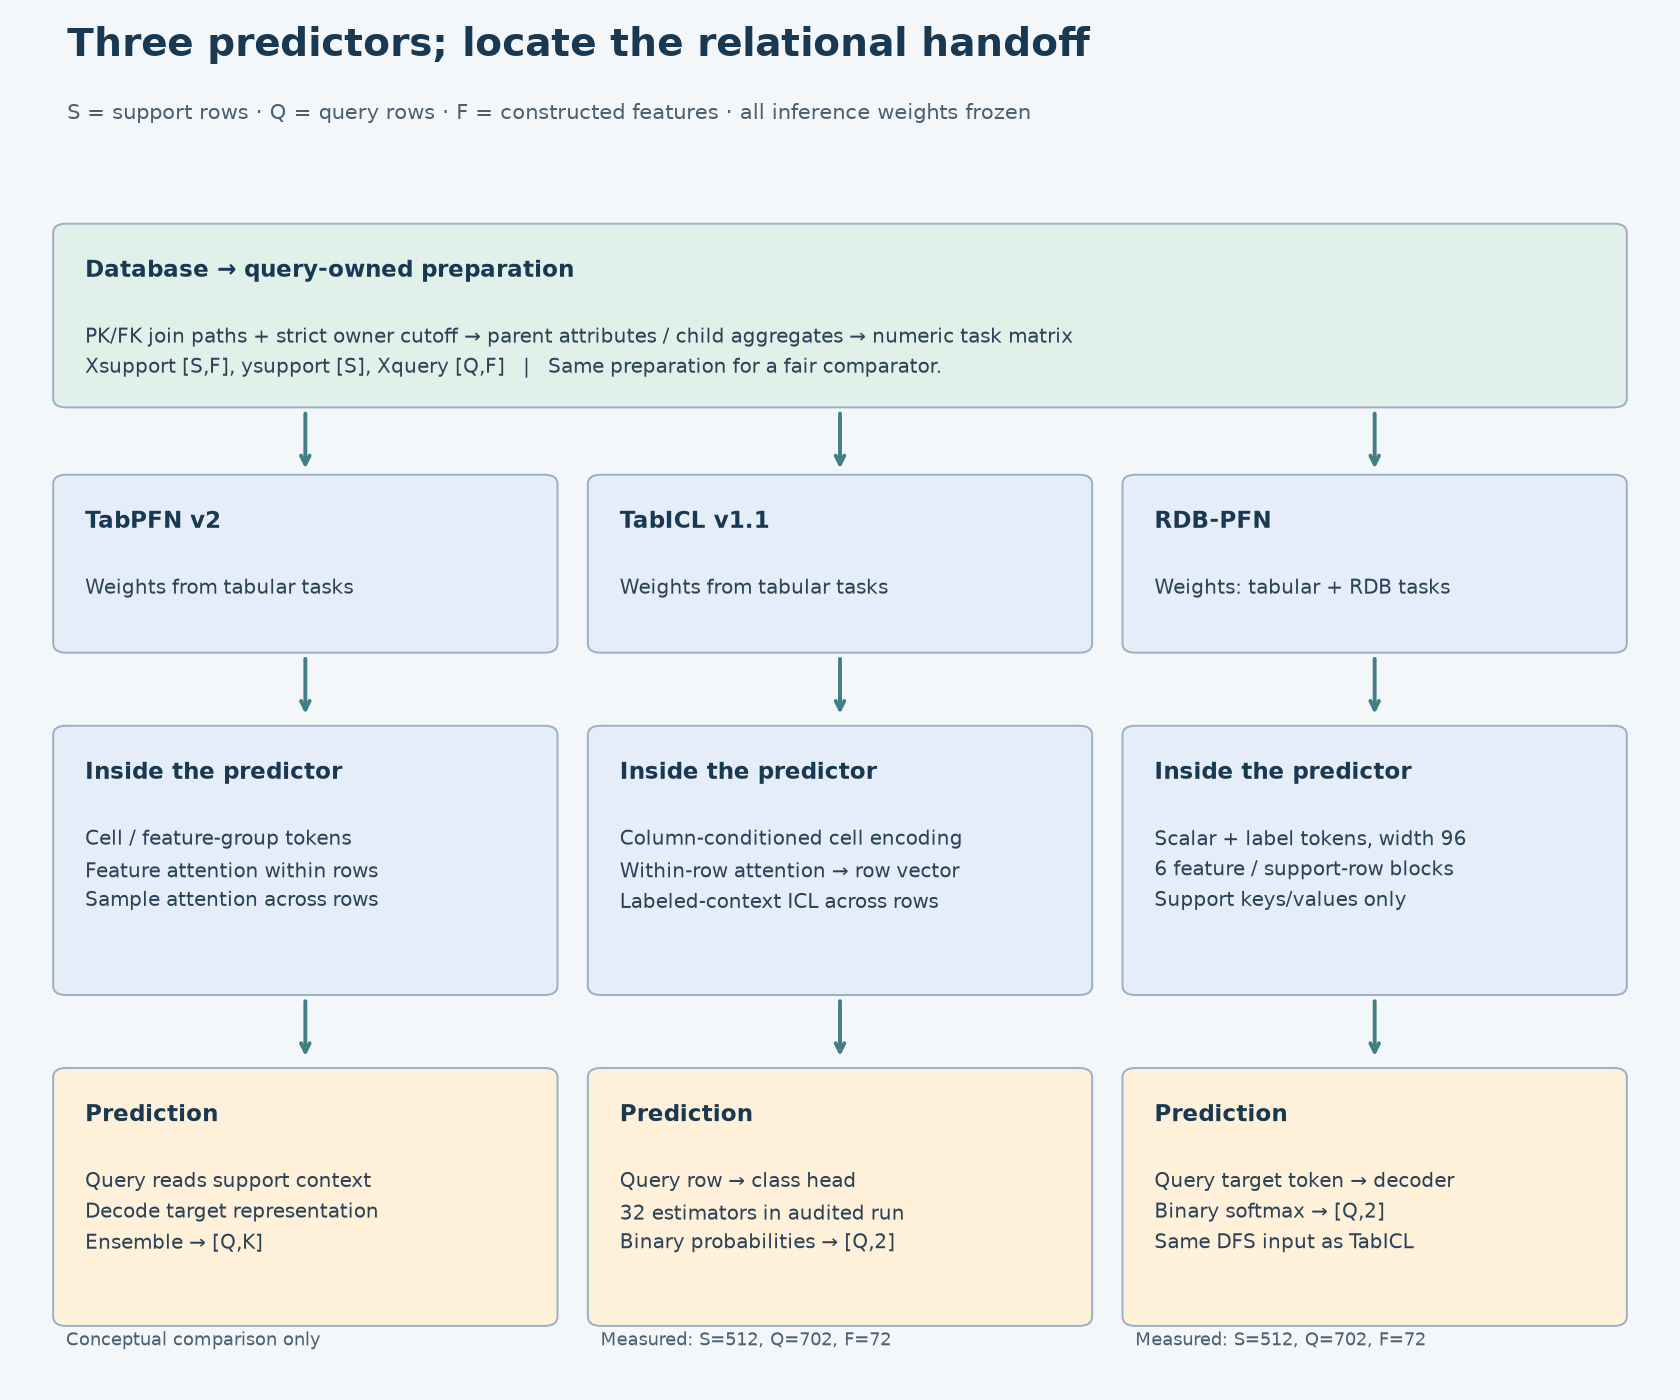<figcaption>Three model-specific routes from a cutoff-safe matrix to predictions. Relational preparation and the pretrained prior are separate; TabPFN is not a measured arm.</figcaption></figure>

The shared interface is `predict(X_support, y_support, X_query)` with frozen weights. The implementations differ. TabPFN v2 alternates attention across features and across examples. TabICL first builds row representations, then performs dataset-level ICL. The released RDB-PFN numeric model alternates feature attention and support-only row attention over a DFS matrix. A shared API does not make their internal operations or pretrained weights interchangeable. See [TabPFN’s architecture](https://www.nature.com/articles/s41586-024-08328-6), [TabICL](https://proceedings.mlr.press/v267/qu25d.html), and [RDB-PFN §§4–5](https://arxiv.org/html/2603.03805v5).

**DFS means Deep Feature Synthesis:** follow relationships and aggregate records into target-row features. It can supply relational information to a tabular FM. RDB-PFN additionally changes the synthetic pretraining distribution. Neither fact means its inference input is the original database graph. In contrast, [Griffin](https://avistian.github.io/relational/lessons/0164-griffin-graph-centric-rdb-fm.html) makes graph structure part of the model’s computation. This distinction explains why “relational” can describe the data preparation, the pretraining prior, or the predictor architecture.

| Component | What carries over | What must be supplied or checked |
|---|---|---|
| Row/cell representation | Encoders can process a constructed numeric table | Keys define joins; arbitrary ID codes do not explain relationships |
| Context inference | Labeled support guides frozen-weight predictions | Every support label must be available at the query time |
| Feature construction | A tabular FM accepts engineered relational summaries | Join path, aggregation and owner cutoff must be explicit |
| Pretraining | Learn a reusable prediction procedure across tasks | A relational synthetic prior changes task distribution; same API does not imply same prior |
| Evaluation | AUROC compares binary rankings | Align complete entity/cutoff keys, label orientation and support draws |

**What cannot transfer automatically:** information discarded by the representation. Child histories `[2,8]` and `[5,5]` both become count 2, mean 5. Any predictor receiving only those two summaries sees identical inputs. It cannot distinguish their spread without another feature or representation. Better pretraining cannot reconstruct which history actually occurred.

Predict before proceeding: can identical count/mean summaries distinguish histories [2,8] and [5,5]? Explain why.

## 3 · Worked trace: the attention mask is only half the contract

Suppose customer 7 has purchases `(day 2, value 4)`, `(day 8, value 8)`, `(day 10, value 100)`, `(day 14, value 12)`. For a prediction at day 10, a strict-past join includes days 2 and 8: count **2**, mean **6**. At day 20, all four are eligible: count **4**, mean **31**. One batch-wide cutoff would corrupt the earlier query.

Now consider three candidate support rows, queried on days 2, 5 and 10. Their labels become available on days 9, 12 and 10. At cutoff 10, this lesson’s strict-before policy allows only the first row. The second row’s features are old enough but its label is not. The third sits exactly on the boundary. In a real task, label availability comes from the target horizon and reporting process; it is not generally the task timestamp.

**Boundary convention changed deliberately.** Lesson 165 allowed a matured label arriving exactly at the current query cutoff (`arrival ≤ cutoff`), while still requiring an earlier context anchor. This fixture uses strict-before availability (`arrival < cutoff`). Neither convention should be inferred from a variable named “time”: write it into the task contract. A context anchored on day 5 whose label arrives on day 10 passes L165's arrival test at day 10 and fails this fixture's test. Its input graph still uses its own day-5 cutoff in both cases.

<figure class="route-figure" tabindex="0">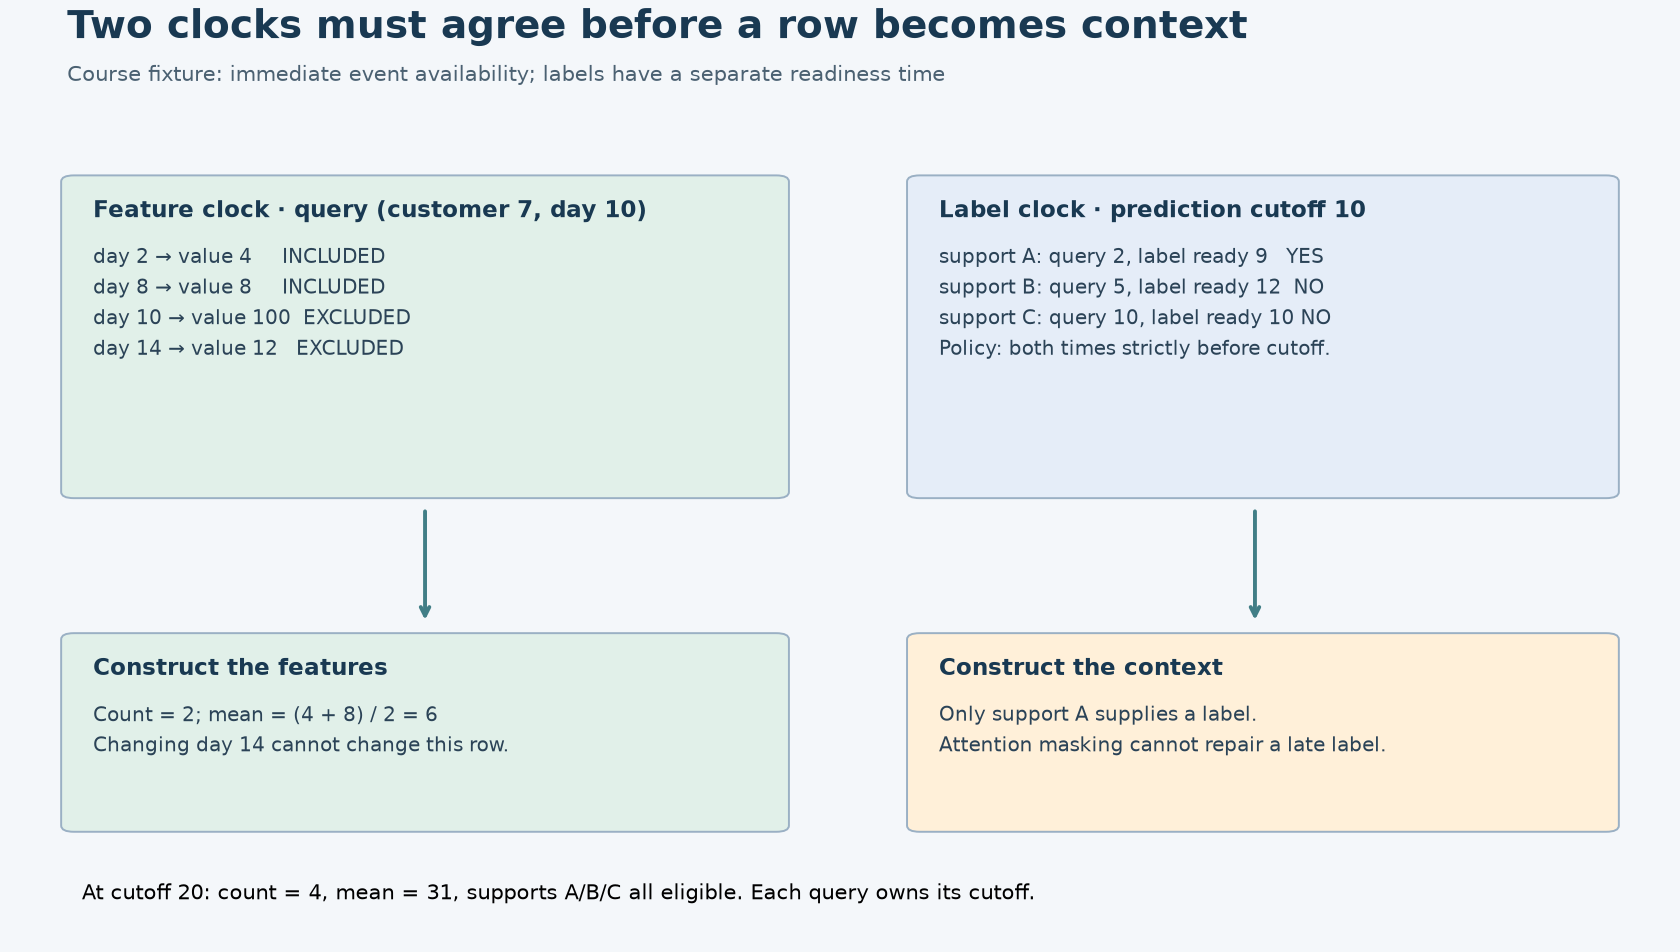<figcaption>The feature clock filters events and the label clock filters support. Both use the individual query cutoff.</figcaption></figure>

Baseline: cutoff 10, final value 12 → count 2, mean 6, support A only. At cutoff 20 → count 4, mean 31, support A/B/C. Recreate and intervene using the code below.

The explorer recomputes **features and eligible support identities**, not model probabilities. Its baseline is cutoff 10, final purchase value 12. Changing that later purchase must leave the baseline features unchanged. At cutoff 20 it should change the mean. This fixture assumes events are available immediately; it does not certify historical availability in RelBench.

Implement the visible contracts in the TODO cells below; the solution notebook supplies reference implementations.

The relational preparation enforces time eligibility; the predictor’s attention mask enforces which supplied rows can act as context. A correct mask still leaks if you feed it labels that were unavailable. The notebook makes you implement both eligibility functions, then tests future-value changes, repeated entities and exact-boundary cases.

## 4 · Reproduce the evidence before interpreting it

The named experiment is [RDB-PFN v5, Table 9](https://arxiv.org/html/2603.03805v5): **rel-f1 / driver-dnf, 512 support rows, seeds 0–9**, three fixed arms. All receive 72 released DFS features and the full 702-query test population. TabICLv1.1 uses **32 estimators**. TabPFN v2 is discussed above but is **not a measured arm here**.

Lesson 166 ran the 30 checkpoint evaluations. Lesson 167 independently verifies **41 input/source files**, regenerates all support draws, aligns `(driverId,date)` identities and recomputes all **21,060 predictions’** AUROCs using average ranks with half-credit ties. No new benchmark inference or cloud job runs in this lesson.

| Model | Paper AUROC | Audited mean ± sample SD | Verdict |
|---|---:|---:|---|
| RDBPFN | 0.7219 | 0.721938 ± 0.019983 | CLOSE |
| RDBPFN_single | 0.6640 | 0.663990 ± 0.034177 | CLOSE |
| TabICLv1.1 | 0.7176 | 0.717568 ± 0.009770 | CLOSE |

<figure class="route-figure" tabindex="0">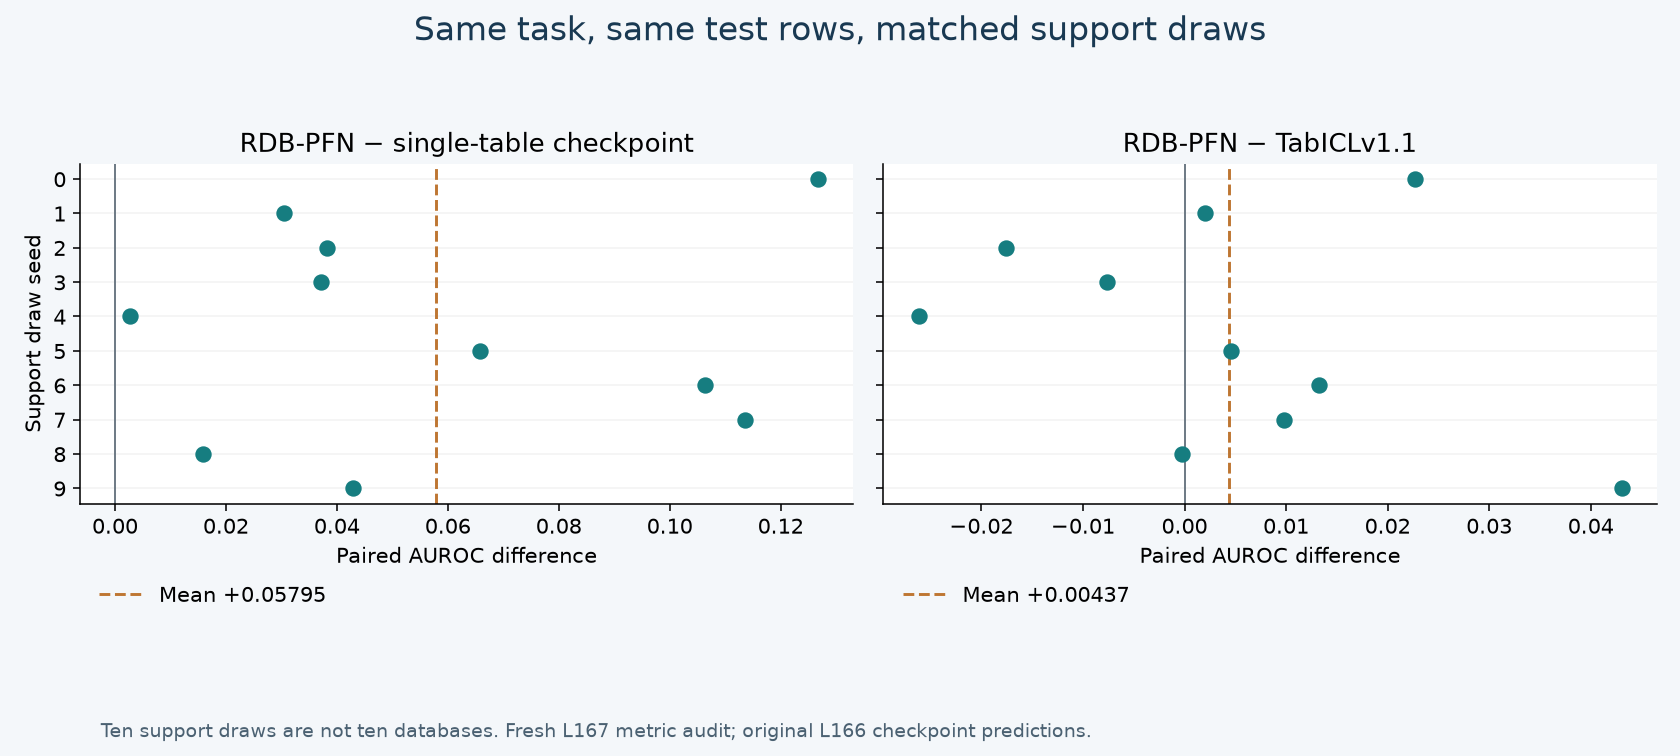<figcaption>All ten paired AUROC differences from the original L166 runs, independently rescored in L167. Repeated support draws on one task do not establish cross-database performance.</figcaption></figure>

The paired RDB-PFN minus single-table checkpoint difference is **+0.05795 AUROC**, positive in all ten draws. Against TabICL it is **+0.00437**, positive in six draws and negative in four. These are ten support draws on **one task**, with overlapping support and the same test population—not ten independent databases. Their variability does not establish cross-database generalization or a causal effect of the prior alone. The single-table checkpoint is the closer comparison, but this replay does not independently recreate its full training history.

**Keep the boundaries visible.** All three means match the paper at four decimals; the inherited descriptive tolerance is 0.02 AUROC, not a statistical equivalence test. Released labels complement the current raw DNF reconstruction documented in L166. Preserve that orientation when replaying: silently calling class 1 “DNF risk” would be wrong. Complement both labels and probabilities to preserve AUROC under the alternate orientation. This lesson audits saved evidence; it does not rerun the SQL reconstruction or original DFS. Historical identity remains `NOT_ESTABLISHED`; fresh pretraining and whole-paper reproduction remain `NOT_RUN`.

## 5 · Your transfer map

Open the notebook and complete three live functions: `temporal_summary`, `eligible_support`, and `keyed_auc`. The last one must reject missing or duplicate keys and align reordered predictions. The full 30-run audit calls your scorer, so a hard-coded toy answer cannot complete the lab.

Then fill the [transfer-map template](https://avistian.github.io/relational/labs/l167-transfer-map-template.md): for **representation, prior, adaptation, time and evaluation**, state what transfers, what must be added, a concrete counterexample, and the evidence boundary. Defend this conclusion in 300–500 words: “A strong relationally prepared tabular baseline tests whether a more specialized relational model adds value.” Do not claim the experiment proves the thesis across databases.

Explain representation, prior, adaptation, time and evidence in your written transfer map.

**Exit check:** explain the count/mean collision; exclude a support label whose window has not closed; reproduce the paired scores; distinguish checkpoint replay from pretraining. Author checks do not mark your learning complete: `PENDING_WRITTEN_DEFENSE`. Tomorrow, redraw the three interfaces without notes. Lesson 168 will ask whether the same reasoning survives an unseen database schema. Ask the agent to review your map or explain any unclear step.

**Primary reading:** [RDB-PFN v5 §§4–5 and Table 9](https://arxiv.org/html/2603.03805v5), comparing the input representation with [TabICL’s two-stage design](https://proceedings.mlr.press/v267/qu25d.html). [Full protocol and runnable fresh-inference lane](https://avistian.github.io/relational/labs/l167-reproduction.md).


In [1]:
# @colab-bootstrap
import os
os.environ.update(OMP_NUM_THREADS="1",OPENBLAS_NUM_THREADS="1",MKL_NUM_THREADS="1")
import base64,hashlib,io,json,zipfile
from pathlib import Path
import numpy as np
P=Path("l167-portable");P.mkdir(exist_ok=True)

## PROVIDED · Original evidence, not hidden computation
The packet contains all 30 raw prediction arrays, original run receipts, prepared data and selected original source bytes. The new audit below verifies them; it never imports the archived model code.

In [2]:
encoded='...'
raw=base64.b64decode(encoded)
assert hashlib.sha256(raw).hexdigest()=='ea04038a79497aa5ae8088634e6ce8d2c0562d0ed668f7f845f10d5fbd60f9ae'
with zipfile.ZipFile(io.BytesIO(raw)) as archive:
    for name in archive.namelist():
        assert not Path(name).is_absolute() and ".." not in Path(name).parts
    archive.extractall(P)
pins={'scope': 'L167 audit of L166 Table9 driver-dnf 512-context saved inference', 'approved': '2026-10-01', 'files': {'evidence/l166/prepared.npz': '9f4a0e9245420127c6391196bdc1a33dba4bbb88bdf3e42161912e3763a20bbe', 'evidence/l166/input-manifest.json': '76d0c10a4f083136dfac5254e57788770381887443b722e47ff9484998206b1f', 'evidence/l166/report.json': 'e258c9ff926c4f0a6d731438ad0c486da8df21883ade2650900e66044a8df6ad', 'sources/l166/source-ledger.json': '45c5caaa403ed1d5aabd51a743563a54cf779a8bf38e093f595f1b25047da8fd', 'evidence/l166/pilot-2/receipt.json': '52efe0d8c66f00859a1c99e65e1806f4d334d23e9d5bf3e31ce731a1bcc4de1f', 'evidence/l166/pilot-2/RDBPFN-0.npz': 'efaaa6982c5c5782e22d35ec4cc9fc82adb33703d8d6ac1206b987b81e4ed9e6', 'evidence/l166/pilot-2/RDBPFN_single-0.npz': 'ec98be9f74006395e5f5cf5a54087dc54cc661eb8f956200781f4c2fa470bfe8', 'evidence/l166/pilot-2/TabICLv1.1-0.npz': 'eff980b9aef9eff48c388721fd2da896f2847390d65605e028b24b334099e681', 'evidence/l166/full-1/receipt.json': 'c80106b3673acb3e6f690292f13eb98d6a606119ac7392a6bfc9c8023f5cc35b', 'evidence/l166/full-1/RDBPFN-1.npz': 'b234f020b1076ea01e1f38dc048e7f3be8aea6dcba21da845d8ca0fca72a7fae', 'evidence/l166/full-1/RDBPFN-2.npz': '874bf69e6c96d57e8a93936cd2d2e46c778ded54ae93edd4b8a62516ae62398f', 'evidence/l166/full-1/RDBPFN-3.npz': '3f01dd8ca7ffeb66f98aea347ef2592f23e1ba70df6f832a97825ae06b113a4b', 'evidence/l166/full-1/RDBPFN-4.npz': 'ae2ddcbdf66ebac5a196349f54a1f4d34c9df98e8660c97e70829606ab4a8dc9', 'evidence/l166/full-1/RDBPFN-5.npz': '02803816d249ca1f275dfed37870f90992aafcd1d30bc53d3a62f64a6456f93f', 'evidence/l166/full-1/RDBPFN-6.npz': 'aae3b3c774b9cc1364770f2037eba3cbf4a7ed7cd6e543432175e92d8ed3bbd2', 'evidence/l166/full-1/RDBPFN-7.npz': '0e74602505fee5446e8da5d2532dc568f1616fbc6af1608e1c70706e36fdc839', 'evidence/l166/full-1/RDBPFN-8.npz': 'd9c3d8b5c2f847d040e7302b607a5e3cec0da79c0e1e4634b5ee75b73592eee6', 'evidence/l166/full-1/RDBPFN-9.npz': 'df98ef5462c41dbdc064760b35caf8ca3819dc9fc6836880410310e4d62aedb2', 'evidence/l166/full-1/RDBPFN_single-1.npz': 'a5d87cde2d885b55a92e1bd248fb562e55a5e1acd9e8ce2c08c86500bf693b50', 'evidence/l166/full-1/RDBPFN_single-2.npz': '1ad0c3c73462f95d4bfb12e6bccdc8c1ed1fe8f219411e84926e0c13d39bc8a7', 'evidence/l166/full-1/RDBPFN_single-3.npz': '72f566d2e5270b35fae3ab9ccc8c60d7f95f06530fa164dc74f77159e5cbec78', 'evidence/l166/full-1/RDBPFN_single-4.npz': 'ee3f8128682b2e9ff168fd14ad11cd629274463f1d30ca65e9a0d5c87b89e69e', 'evidence/l166/full-1/RDBPFN_single-5.npz': 'bf966a1143912259be2aff2f8d1e1460992039363c347960234f204c58e14075', 'evidence/l166/full-1/RDBPFN_single-6.npz': 'bbd130e58fbd44eec1783a78019adccb15bd6eace254af5f32ee0aaae8ecf989', 'evidence/l166/full-1/RDBPFN_single-7.npz': '02a158e9d726f4553f9e8c76d17810ccf1d2e8c5c4e9de964a0ca7b64b9e2389', 'evidence/l166/full-1/RDBPFN_single-8.npz': '85bb14ba7154e7aa90e794f9a49e478b1d35e6e064031964d3715e215b72b18b', 'evidence/l166/full-1/RDBPFN_single-9.npz': '693cf63d27383e8e603de6ae4f30f993cf4e5bf19afb46972d3c169c03bc6659', 'evidence/l166/full-1/TabICLv1.1-1.npz': 'd25c341b6145eed5380866e54ae6f4753d798f9d461125dce1ad41ef1a6efa14', 'evidence/l166/full-1/TabICLv1.1-2.npz': '8b9f2f0b0f9dcacea0ae95923e56fd961e3ffbbc361c4b6ed8535a954b971bfe', 'evidence/l166/full-1/TabICLv1.1-3.npz': '85c55bb62822daa0e305b552f3a0a6ce9149feec8a80c5f8762a92ac6a0b1f44', 'evidence/l166/full-1/TabICLv1.1-4.npz': '8d8f2e3eaa791be21f31f939e2011bfe016269e35b8a3371473dcda9454e7022', 'evidence/l166/full-1/TabICLv1.1-5.npz': '3000d3e27cd2288ad33b9161f8bb313d6ce34a5b9bd21f5f3050e6b2d1937083', 'evidence/l166/full-1/TabICLv1.1-6.npz': '91eb8ebecd2c4b71cb6bf40c1f001f44e403d8005b4e612675b9cc59309de69f', 'evidence/l166/full-1/TabICLv1.1-7.npz': '353f764d50857e8386ac204aca05d34d044f07832f9ff95e5cbe7784a3be0ead', 'evidence/l166/full-1/TabICLv1.1-8.npz': 'e2269ccfca7cd52c45334786489856103e544b9b244363452ee64b26f4cb7226', 'evidence/l166/full-1/TabICLv1.1-9.npz': '1025f3d8eff81dea26b142a78c33af9ff95a0b02d8d477804ffb1f52233218e9', 'sources/l166/upstream/model_pretrain/src/models.py': '0c64761bca8c484b4fd92ebe129ae4d1420ce1eb9caf46f477690eb81bb07a8b', 'sources/l166/upstream/model_pretrain/src/eval.py': 'e4d7330238bfa086c897e9f08b4ad2c2d2e6ff6627cc0c5daa33ea3d04166bc6', 'sources/l166/upstream/model_pretrain/src/eval_classifiers.py': 'd36a2401e3b238f8dfc79b0e3709bb27f00deeb7b57d5fe38f5862c462f9e128', 'sources/l166/upstream/model_pretrain/conf_eval/model/tabiclv11.yaml': '8959045ea8c5bbc51222c4e85653c5eb037d477b76a64a634116f168e92ff39e', 'sources/l166/upstream/model_pretrain/conf_eval/dataset/full-512.yaml': '40173dd1bba6ab5f9c94f6524c72a6ce32b14972fada5c573718449359fb4ff1'}}
print("Authenticated all original evidence files")

Authenticated all original evidence files


## TODO · Aggregate events at each owner cutoff.

**Contract:** Queries are unique numeric[entity,cutoff] pairs; events are numeric[entity,event_time,value] triples. Return[count,mean] per query in its original order. Keep only matching entities with event_time<cutoff. Empty groups become[0,0]. Reject malformed/nonfinite input or duplicate query keys with ValueError.

In [3]:
def temporal_summary(queries, events):
    """Course fixture: [entity,cutoff] queries; [entity,event_time,value] events.

    Return [count,mean] for matching events strictly before each owner cutoff.
    Event time is assumed to equal availability time ONLY in this fixture.
    """
    import numpy as np
    q=np.asarray(queries);e=np.asarray(events)
    if q.ndim!=2 or q.shape[1]!=2 or e.ndim!=2 or e.shape[1]!=3:
        raise ValueError('Expected query pairs and event triples')
    if not np.isfinite(q).all() or not np.isfinite(e).all():
        raise ValueError('Nonfinite fixture input')
    if len(set(map(tuple,q)))!=len(q):raise ValueError('Duplicate query keys')
    result=[]
    for entity,cutoff in q:
        values=e[(e[:,0]==entity)&(e[:,1]<cutoff),2]
        result.append([len(values),float(values.mean()) if len(values) else 0.])
    return np.asarray(result,dtype=float).reshape(-1,2)

In [4]:
# CHECK
np.testing.assert_allclose(temporal_summary([[7,10],[7,20]],[[7,2,4],[7,8,8],[7,10,100],[7,14,12]]),[[2,6],[4,31]])
print('CHECK: every query owns its cutoff')

CHECK: every query owns its cutoff


## TODO · Separate old features from available labels.

**Contract:** keys contains unique[entity,query_time] rows; label_ready gives their label availability times, never earlier than query_time. Return original indices where BOTH query_time and label_ready are strictly below cutoff. Reject bad shapes, duplicates, nonfinite values or impossible readiness with ValueError.

In [5]:
def eligible_support(keys, label_ready, cutoff):
    """Return indices whose query time AND label availability precede cutoff."""
    import numpy as np
    k=np.asarray(keys);ready=np.asarray(label_ready)
    if k.ndim!=2 or k.shape[1]!=2 or ready.shape!=(len(k),):
        raise ValueError('Invalid support shape')
    if not np.isfinite(k).all() or not np.isfinite(ready).all() or not np.isfinite(cutoff):
        raise ValueError('Nonfinite support input')
    if len(set(map(tuple,k)))!=len(k) or np.any(ready<k[:,1]):
        raise ValueError('Duplicate keys or labels ready before prediction time')
    return np.flatnonzero((k[:,1]<cutoff)&(ready<cutoff))

In [6]:
# CHECK
np.testing.assert_array_equal(eligible_support([[7,2],[8,5],[9,10]],[9,12,10],10),[0])
print('CHECK: only support A is available')

CHECK: only support A is available


## TODO · Score the exact prediction population after alignment.

**Contract:** expected_keys and prediction_keys are unique[entity,cutoff] pairs. Labels align to expected_keys; probabilities align to prediction_keys. Require identical complete key sets, both label classes 0/1, finite probabilities in[0,1]. Reorder by keys; compute AUROC with half-credit ties. Reject invalid inputs with ValueError.

In [7]:
def keyed_auc(expected_keys, labels, prediction_keys, probabilities):
    """Align exact composite identities; AUROC from average ranks (ties=half)."""
    import numpy as np
    expected=np.asarray(expected_keys);got=np.asarray(prediction_keys)
    y=np.asarray(labels);p=np.asarray(probabilities,dtype=float)
    for keys in (expected,got):
        if keys.ndim!=2 or keys.shape[1]!=2 or len(set(map(tuple,keys)))!=len(keys):
            raise ValueError('Duplicate or malformed composite keys')
    if y.shape!=(len(expected),) or p.shape!=(len(got),) or set(y)!={0,1}:
        raise ValueError('Invalid label/prediction population')
    if not np.isfinite(p).all() or np.any((p<0)|(p>1)):
        raise ValueError('Invalid class-1 probabilities')
    lookup=dict(zip(map(tuple,got),p))
    if set(lookup)!=set(map(tuple,expected)):raise ValueError('Incomplete or extra query keys')
    scores=np.array([lookup[tuple(key)] for key in expected])
    order=np.argsort(scores,kind='stable');sorted_scores=scores[order]
    ranks=np.empty(len(scores),dtype=float);i=0
    while i<len(scores):
        j=i+1
        while j<len(scores) and sorted_scores[j]==sorted_scores[i]:j+=1
        ranks[order[i:j]]=(i+1+j)/2.;i=j
    positives=int(y.sum());negatives=len(y)-positives
    return float((ranks[y==1].sum()-positives*(positives+1)/2)/(positives*negatives))

In [8]:
# CHECK
keys=[[1,10],[1,20],[2,10],[2,20]]
assert keyed_auc(keys,[0,1,0,1],keys[::-1],[1.,.5,.5,.1])==.875
print('CHECK: shuffled predictions and tied scores align correctly')

CHECK: shuffled predictions and tied scores align correctly


In [9]:
def check167(summary_fn, support_fn, auc_fn):
    import numpy as np
    queries=[[7,10],[7,20],[9,10]]
    events=[[7,2,4],[7,8,8],[7,10,100],[7,14,12],[9,12,99]]
    np.testing.assert_allclose(summary_fn(queries,events),[[2,6],[4,31],[0,0]])
    np.testing.assert_allclose(summary_fn(queries,events[::-1]),[[2,6],[4,31],[0,0]])
    np.testing.assert_array_equal(support_fn([[7,2],[8,5],[9,10]],[9,12,10],10),[0])
    keys=[[1,10],[1,20],[2,10],[2,20]]
    assert auc_fn(keys,[0,1,0,1],keys[::-1],[1.,.5,.5,.1])==.875
    for bad_keys,bad_p in [(keys[:-1],[.1,.5,.5]),(keys+[keys[0]],[.1,.5,.5,1.,.1]),(keys,[.1,.5,float('nan'),1.])]:
        try:auc_fn(keys,[0,1,0,1],bad_keys,bad_p)
        except ValueError:pass
        else:raise AssertionError('Invalid prediction population accepted')
    return 'PASS'

In [10]:
assert check167(temporal_summary,eligible_support,keyed_auc)=="PASS"
# Intervention: change only the future purchase; observe both query cutoffs.
for cutoff in [10,20]:
    for value in [12,1200]:
        features=temporal_summary([[7,cutoff]],[[7,2,4],[7,8,8],[7,10,100],[7,14,value]])[0]
        support=eligible_support([[7,2],[8,5],[9,10]],[9,12,10],cutoff)
        if cutoff==10:np.testing.assert_allclose(features,[2,6])
        else:np.testing.assert_allclose(features,[4,(112+value)/4])
        print(cutoff,value,"features",features.tolist(),"support indices",support.tolist())
# Representation collision, regardless of predictor architecture.
a=temporal_summary([[7,10]],[[7,1,2],[7,2,8]])
b=temporal_summary([[7,10]],[[7,1,5],[7,2,5]])
np.testing.assert_array_equal(a,b)
print("Different histories, identical count/mean inputs")

10 12 features [2.0, 6.0] support indices [0]
10 1200 features [2.0, 6.0] support indices [0]
20 12 features [4.0, 31.0] support indices [0, 1, 2]
20 1200 features [4.0, 328.0] support indices [0, 1, 2]
Different histories, identical count/mean inputs


## PROVIDED · Complete independent saved-evidence audit
Read the code: it checks 41 file hashes against pinned inputs and original manifests/receipts, regenerates the support schedule, and calls **your keyed_auc** for all 30 original runs. Rank scoring here is independently implemented from L166; author tests additionally compare sklearn and explicit positive/negative pairs.

In [11]:
def audit167(root, pins, auc_fn):
    import hashlib,json
    from pathlib import Path
    import numpy as np
    root=Path(root)
    for name,digest in pins['files'].items():
        if hashlib.sha256((root/name).read_bytes()).hexdigest()!=digest:
            raise ValueError('Artifact hash mismatch: '+name)
    e=root/'evidence/l166'
    manifest=json.loads((e/'input-manifest.json').read_text())
    if pins['files']['evidence/l166/prepared.npz']!=manifest['files']['prepared.npz']['sha256']:
        raise ValueError('Original prepared-data hash mismatch')
    source=json.loads((root/'sources/l166/source-ledger.json').read_text())
    for name,digest in pins['files'].items():
        if name.startswith('sources/l166/upstream/'):
            if digest!=source['files'][name.removeprefix('sources/l166/')]:
                raise ValueError('Original source hash mismatch')
    with np.load(e/'prepared.npz',allow_pickle=False) as data:
        train=data['train_keys'];keys=data['test_keys'];labels=data['y_test'];supports=data['support']
        if train.shape!=(11411,2) or keys.shape!=(702,2) or data['X_train'].shape!=(11411,72) or data['X_test'].shape!=(702,72):
            raise ValueError('Selected population changed')
        if len(set(map(tuple,train)))!=len(train) or len(set(map(tuple,keys)))!=len(keys):
            raise ValueError('Duplicate prepared identities')
        if set(map(tuple,train))&set(map(tuple,keys)):raise ValueError('Train/test key overlap')
        if supports.shape!=(10,512):raise ValueError('Incomplete support schedule')
        for seed in range(10):
            integer=int.from_bytes(hashlib.sha256(f'rel-f1-dfs-2:driver-dnf:{seed}'.encode()).digest()[:4],'big')
            indices=np.random.default_rng(integer).choice(len(train),512,replace=False)
            if not np.array_equal(indices,supports[seed]):raise ValueError('Support seed schedule mismatch')
    targets={'RDBPFN':.7219,'RDBPFN_single':.6640,'TabICLv1.1':.7176}
    expected={(a,s) for a in targets for s in range(10)};seen=set();scores={a:{} for a in targets}
    manifest_hash=hashlib.sha256((e/'input-manifest.json').read_bytes()).hexdigest()
    for folder in ['pilot-2','full-1']:
        receipt=json.loads((e/folder/'receipt.json').read_text())
        if receipt['input_manifest_sha256']!=manifest_hash:raise ValueError('Original receipt input hash mismatch')
        for row in receipt['records']:
            arm,seed=row['arm'],row['seed'];identity=(arm,seed)
            if identity not in expected or identity in seen:raise ValueError('Unexpected/duplicate selected run')
            seen.add(identity);path=e/folder/f'{arm}-{seed}.npz'
            if hashlib.sha256(path.read_bytes()).hexdigest()!=row['sha256']:raise ValueError('Original receipt prediction hash mismatch')
            with np.load(path,allow_pickle=False) as result:
                if not np.array_equal(result['support_keys'],train[supports[seed]]):raise ValueError('Unpaired support identities')
                # Check labels by key independently of serialization order.
                if len(result['keys'])!=len(keys) or len(set(map(tuple,result['keys'])))!=len(keys):raise ValueError('Incomplete query keys')
                label_map=dict(zip(map(tuple,result['keys']),result['label']))
                if label_map!=dict(zip(map(tuple,keys),labels)):raise ValueError('Labels differ by query key')
                score=auc_fn(keys,labels,result['keys'],result['probability'])
                if abs(score-row['auc'])>1e-12:raise ValueError('Original receipt metric mismatch')
                scores[arm][seed]=score
    if seen!=expected:raise ValueError('Missing selected runs')
    models={};vectors={}
    for arm,target in targets.items():
        v=np.array([scores[arm][seed] for seed in range(10)]);vectors[arm]=v
        models[arm]=dict(per_seed=v.tolist(),mean=float(v.mean()),sample_sd=float(v.std(ddof=1)),paper=target,
                         status='CLOSE' if abs(v.mean()-target)<=.02 else 'OUTSIDE_TOLERANCE')
    paired={}
    for arm in ['RDBPFN_single','TabICLv1.1']:
        d=vectors['RDBPFN']-vectors[arm]
        paired[arm]=dict(per_seed=d.tolist(),mean=float(d.mean()),sample_sd=float(d.std(ddof=1)),
                         min=float(d.min()),max=float(d.max()),positive_seeds=int((d>0).sum()))
    return dict(experiment=pins['scope'],status='COMPLETE_SAVED_EVIDENCE_AUDIT',runs=30,predictions=21060,
                queries=702,features=72,support_rows=512,seeds=list(range(10)),models=models,paired=paired,
                hashed_files=len(pins['files']),support_schedule='INDEPENDENTLY_REGENERATED',
                new_benchmark_inference='NOT_RUN',fresh_pretraining='NOT_RUN',whole_paper='NOT_RUN',
                historical_identity='NOT_ESTABLISHED',additional_paid_compute_usd=0,learner='PENDING_WRITTEN_DEFENSE')

In [12]:
report=audit167(P,pins,keyed_auc)
assert report["runs"]==30 and report["predictions"]==21060
Path("l167-report.json").write_text(json.dumps(report,indent=2)+"\n")
for arm,row in report["models"].items():print(arm,round(row["mean"],6),"SD",round(row["sample_sd"],6),row["status"])
for arm,row in report["paired"].items():print("RDBPFN minus",arm,round(row["mean"],6),"positive draws",row["positive_seeds"])
print("Fresh metric audit COMPLETE; new inference/pretraining NOT_RUN; historical identity NOT_ESTABLISHED")

RDBPFN 0.721938 SD 0.019983 CLOSE
RDBPFN_single 0.66399 SD 0.034177 CLOSE
TabICLv1.1 0.717568 SD 0.00977 CLOSE
RDBPFN minus RDBPFN_single 0.057948 positive draws 10
RDBPFN minus TabICLv1.1 0.004369 positive draws 6
Fresh metric audit COMPLETE; new inference/pretraining NOT_RUN; historical identity NOT_ESTABLISHED


## EXIT · Transfer map and written defense
Fill all five rows with carries_over, requires, counterexample, evidence_limit. Write 300–500 words. Rubric 0–2 each: representation, prior/adaptation, time, fair comparison, evidence limits. Target ≥8/10 and no zero; teacher review required. The solution provides illustrative rows, not proof of your mastery. For a new full inference run, use the separate [L166 lane](https://avistian.github.io/relational/labs/l166-reproduction.md); default execution does not run it.

In [13]:
transfer_map={'representation': {'carries_over': 'Numeric row inputs', 'requires': 'FK joins and appropriate summaries', 'counterexample': '[2,8] and [5,5] collide under count/mean', 'evidence_limit': 'Constructive fixture, not benchmark superiority'}, 'prior': {'carries_over': 'Pretrained prediction procedure', 'requires': 'Audit training distribution', 'counterexample': 'Identical API, different synthetic tasks', 'evidence_limit': 'No fresh pretraining'}, 'adaptation': {'carries_over': 'Frozen-weight labeled context', 'requires': 'Support/query label separation', 'counterexample': 'Using a query target as support', 'evidence_limit': 'Mask does not certify availability'}, 'time': {'carries_over': 'Temporal evaluation discipline', 'requires': 'Feature and label availability', 'counterexample': 'Query5 label ready12 at cutoff 10', 'evidence_limit': 'Immediate event availability is a fixture assumption'}, 'evaluation': {'carries_over': 'AUROC and paired comparison', 'requires': 'Full entity/date keys and matched supports', 'counterexample': 'Same entity at two cutoffs scored as one key', 'evidence_limit': 'Ten support draws on one task'}}
defense="" # Write your own 300–500 word defense.
Path("l167-submission.json").write_text(json.dumps(dict(transfer_map=transfer_map,defense=defense,review=None,learner="PENDING_WRITTEN_DEFENSE"),indent=2)+"\n")
print("Learner PENDING_WRITTEN_DEFENSE")

Learner PENDING_WRITTEN_DEFENSE
